# CS-VQE toy example + Gibbs low-sector effective Hamiltonian

This notebook does two things:

1. **Reproduces the logic of the CS-VQE paper on a tiny, non-trivial 3-qubit example** using the same Pauli-string dictionary format used in the `CS_VQE_how_to_use.ipynb` notebook.
2. **Adds a Gibbs low-sector truncation** in the eigenbasis of $H_{nc}$.

That second part is **not part of the original CS-VQE paper**. It is an extra extension motivated by your postdoc's suggestion:

- diagonalize $H_{nc}$,
- compute Gibbs weights $p_j = e^{-\beta E_j}/Z$,
- keep the states with $p_j \ge p_{\min}$,
- build the projector $P_{\mathrm{low}}$ onto that low-temperature sector,
- define the effective Hamiltonian
  \[
  H_{\mathrm{eff}} = P_{\mathrm{low}} H P_{\mathrm{low}}.
  \]

The paper itself decomposes the Hamiltonian as
\[
H = H_{nc} + H_c,
\]
and then uses the **noncontextual ground state of $H_{nc}$** to define the contextual subspace. The quantum correction is then computed inside that restricted subspace. In the paper's 3-qubit example, the contextual correction already reduces to a 2-qubit problem.

## Why this small example is non-trivial

We use the explicit 3-qubit term structure from Section 2.4 of the CS-VQE paper:

\[
S_{nc} = \{ZII, IXI, IYI, IZX, IZY, IZZ, ZXI, ZYI, ZZX, ZZY, ZZZ\},
\]
\[
S_c = \{IIX, IIY, IIZ\}.
\]

This is a good toy example because:

- $H_{nc}$ is **noncontextual**, but it is **not trivial**,
- the full Hamiltonian $H = H_{nc} + H_c$ is contextual,
- the paper shows that the contextual correction becomes a **2-qubit** problem in this example,
- the Hilbert space is still small enough that we can diagonalize everything exactly and visualize the low sector.

We will choose concrete coefficients so that the Gibbs distribution over the eigenstates of $H_{nc}$ is strongly concentrated in a small number of states. That makes the low-sector projection easy to see in plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=6, suppress=True)


In [2]:
# --- 3-qubit toy Hamiltonian from the paper's term structure ---
# The term sets follow Section 2.4 of the paper.
# The coefficients below are a deterministic choice for a clean demo.

ham_nc = {
    'ZII': -1.20,
    'IXI': -0.85,
    'IYI':  0.25,
    'IZX': -0.55,
    'IZY':  0.15,
    'IZZ': -0.70,
    'ZXI': -0.65,
    'ZYI':  0.20,
    'ZZX': -0.45,
    'ZZY':  0.10,
    'ZZZ': -0.40,
}

ham_c = {
    'IIX': -0.50,
    'IIY':  0.30,
    'IIZ': -0.60,
}

ham = dict(ham_nc)
ham.update(ham_c)

print('Number of H_nc terms:', len(ham_nc))
print('Number of H_c  terms:', len(ham_c))
print('Number of H    terms:', len(ham))


Number of H_nc terms: 11
Number of H_c  terms: 3
Number of H    terms: 14


In [3]:
# --- Minimal contextuality test, matching the logic used in cs_vqe.py ---
# This makes the notebook self-contained even if the cs_vqe module is not installed.

def commute(pauli_a: str, pauli_b: str) -> bool:
    assert len(pauli_a) == len(pauli_b)
    sign = 1
    for a, b in zip(pauli_a, pauli_b):
        if a != 'I' and b != 'I' and a != b:
            sign *= -1
    return sign == 1


def contextualQ(terms):
    """Return True if the set of Pauli strings is contextual.
    This follows the same criterion used in the CS-VQE code:
    look for a triple where exactly one pair anticommutes.
    """
    T, Z = [], []
    for i in range(len(terms)):
        if any(not commute(terms[i], terms[j]) for j in range(len(terms))):
            T.append(terms[i])
        else:
            Z.append(terms[i])

    for i in range(len(T)):
        for j in range(len(T)):
            for k in range(j, len(T)):
                if i != j and i != k and commute(T[i], T[j]) and commute(T[i], T[k]) and not commute(T[j], T[k]):
                    return True
    return False


def contextualQ_ham(ham_dict):
    return contextualQ(list(ham_dict.keys()))


print('H_nc contextual? ', contextualQ_ham(ham_nc))
print('H    contextual? ', contextualQ_ham(ham))


H_nc contextual?  False
H    contextual?  True


The expected output is:

- `H_nc contextual? False`
- `H contextual? True`

So this is a genuine **non-trivial** example: the full Hamiltonian is contextual, but the chosen $H_{nc}$ is not.

In [4]:
# --- Optional: use the actual cs_vqe module if you already have it installed ---
# This follows the same workflow as the CS_VQE_how_to_use.ipynb notebook.

try:
    import cs_vqe as c
    HAVE_CSVQE = True
except ImportError:
    HAVE_CSVQE = False
    print('cs_vqe is not installed in this environment. The self-contained part of the notebook will still run.')

if HAVE_CSVQE:
    print('cs_vqe imported successfully.')
    print('contextualQ_ham(H_nc) from module:', c.contextualQ_ham(ham_nc))
    print('contextualQ_ham(H)    from module:', c.contextualQ_ham(ham))


cs_vqe imported successfully.
contextualQ_ham(H_nc) from module: False
contextualQ_ham(H)    from module: True


## Paper-style CS-VQE objects (same data format as the uploaded notebook)

If `cs_vqe` is available, the next cell reproduces the same sequence used in the tutorial notebook:

- `model = c.quasi_model(ham_nc)`
- `fn_form = c.energy_function_form(ham_nc, model)`
- `gs_noncon = c.find_gs_noncon(ham_nc, ...)`
- `ep_state = gs_noncon[1]`
- `c.get_reduced_hamiltonians(...)`

This is the **paper-style CS-VQE flow**.

The later Gibbs-sector projection is a separate extension.

In [5]:
if HAVE_CSVQE:
    model = c.quasi_model(ham_nc)
    fn_form = c.energy_function_form(ham_nc, model)
    gs_noncon = c.find_gs_noncon(ham_nc, model=model, fn_form=fn_form)
    ep_state = gs_noncon[1]

    print('Noncontextual energy estimate:', gs_noncon[0])
    print('ep_state:', ep_state)

    # For this 3-qubit example, an order like [0,1,2] is enough for a demo.
    reduced_hamiltonians = c.get_reduced_hamiltonians(ham, model, fn_form, ep_state, order=[0, 1, 2])

    print('\nReduced Hamiltonians returned by cs_vqe:')
    for k, h_red in enumerate(reduced_hamiltonians):
        print(f'  quantum qubits = {k}: {h_red}')
else:
    print('Skipping the cs_vqe API demo because cs_vqe is not importable here.')


Noncontextual energy estimate: -3.3737065118553913
ep_state: [[1], [0.5060527288072486, -0.11501020352073776, 0.46004745351784304, -0.20701853946543408, 0.6900601086732968]]

Reduced Hamiltonians returned by cs_vqe:
  quantum qubits = 0: {'I': -3.3737065118553917, 'X': -0.0840400889865777, 'Y': -0.08890176743027492, 'Z': -0.819246895439744}
  quantum qubits = 1: {'ZI': -2.110886244488732, 'II': -1.262820267366659, 'IX': -0.0840400889865777, 'IY': -0.08890176743027492, 'IZ': -0.819246895439744}
  quantum qubits = 2: {'ZII': -1.2, 'IXZ': -0.029598383307791076, 'IZI': 1.262820267366659, 'IYI': -0.018022369797764365, 'IXX': -0.06328948735050088, 'IXY': 0.008862449511716719, 'ZXZ': 0.029614753838317798, 'ZZI': 0.9108862444887325, 'ZYI': 0.01802830156036439, 'ZXX': 0.0632897020626369, 'ZXY': -0.008866223095562967, 'IYY': -0.04027238859818653, 'IIX': -0.038397636889431964, 'IZY': -0.01661009699616595, 'IIZ': -0.819246895439744, 'IYX': 0.1106634457254919, 'IIY': -0.10551186442644087, 'IZX': 0.

## Matrix utilities

For the Gibbs-sector part we now work directly with matrices. This is exact for the 3-qubit example.

In [7]:
PAULI = {
    'I': np.array([[1, 0], [0, 1]], dtype=complex),
    'X': np.array([[0, 1], [1, 0]], dtype=complex),
    'Y': np.array([[0, -1j], [1j, 0]], dtype=complex),
    'Z': np.array([[1, 0], [0, -1]], dtype=complex),
}


def pauli_string_matrix(pauli_string: str) -> np.ndarray:
    out = np.array([[1]], dtype=complex)
    for ch in pauli_string:
        out = np.kron(out, PAULI[ch])
    return out


def ham_dict_to_matrix(ham_dict):
    n = len(next(iter(ham_dict.keys())))
    dim = 2 ** n
    H = np.zeros((dim, dim), dtype=complex)
    for p, coeff in ham_dict.items():
        H += coeff * pauli_string_matrix(p)
    return H


H_nc = ham_dict_to_matrix(ham_nc)
H_c = ham_dict_to_matrix(ham_c)
H = ham_dict_to_matrix(ham)

print('Matrix dimension:', H.shape)


Matrix dimension: (8, 8)


## Exact diagonalization of $H_{nc}$

This is the part your postdoc's suggestion starts from.

We diagonalize
$$
H_{nc}\,|\phi_j\rangle = E_j^{(nc)} |\phi_j\rangle.
$$

Then for a chosen inverse temperature $\beta$, we define the Gibbs weights
$$
p_j = \frac{e^{-\beta E_j^{(nc)}}}{Z_{nc}},
\qquad
Z_{nc} = \sum_j e^{-\beta E_j^{(nc)}}.
$$

If we impose a probability threshold $p_{\min}$, then the retained sector is
$$
\mathcal S_{\mathrm{low}} = \{j : p_j \ge p_{\min}\}.
$$

Equivalently, this is an energy cutoff
$$
E_j^{(nc)} \le E_{\mathrm{cut}} = -\frac{1}{\beta}\log(p_{\min} Z_{nc}).
$$

That is where the phrase “the effective Hamiltonian is the low sector Hamiltonian following the Gibbs weights” comes from.

In [8]:
evals_nc, evecs_nc = np.linalg.eigh(H_nc)

beta = 1.30
p_min = 1.0e-2

boltz = np.exp(-beta * evals_nc)
Z_nc = boltz.sum()
weights = boltz / Z_nc
E_cut = -(1.0 / beta) * np.log(p_min * Z_nc)
selected = np.where(weights >= p_min)[0]

print('Eigenvalues of H_nc:')
print(evals_nc)
print('\nGibbs weights of H_nc eigenstates:')
print(weights)
print('\nSelected indices:', selected)
print('Energy cutoff E_cut:', E_cut)
print('Selected energies:', evals_nc[selected])


Eigenvalues of H_nc:
[-3.373707 -3.373707  0.819211  0.819211  0.973707  0.973707  1.580789
  1.580789]

Gibbs weights of H_nc eigenstates:
[0.495344 0.495344 0.002126 0.002126 0.00174  0.00174  0.00079  0.00079 ]

Selected indices: [0 1]
Energy cutoff E_cut: -0.3716548304854907
Selected energies: [-3.373707 -3.373707]


In [9]:
# Check that the probability-threshold rule and energy-threshold rule agree.
selected_from_Ecut = np.where(evals_nc <= E_cut + 1e-12)[0]
print('Selected from E_cut:', selected_from_Ecut)
assert np.array_equal(selected, selected_from_Ecut)


Selected from E_cut: [0 1]


## Build the low-sector projector and the effective Hamiltonian

Let
$$
P_{\mathrm{low}} = \sum_{j\in \mathcal S_{\mathrm{low}}} |\phi_j\rangle\langle \phi_j|.
$$

Then the effective Hamiltonian is
$$
H_{\mathrm{eff}} = P_{\mathrm{low}} H P_{\mathrm{low}}.
$$

There are two useful ways to look at it:

1. **As an operator on the full 8-dimensional space**: it is zero outside the selected sector.
2. **As a reduced operator on the selected subspace only**:
   $$
   H_{\mathrm{eff}}^{(\mathrm{sector})} = V_{\mathrm{low}}^{\dagger} H V_{\mathrm{low}},
   $$
   where the columns of $V_{\mathrm{low}}$ are the selected eigenvectors of $H_{nc}$.

This second one is usually the most convenient effective Hamiltonian to actually work with.

In [10]:
V_nc = evecs_nc
V_low = V_nc[:, selected]

P_low = V_low @ V_low.conj().T
H_eff_fullspace = P_low @ H @ P_low
H_eff_sector = V_low.conj().T @ H @ V_low

# Also useful for inspection in the H_nc eigenbasis.
H_in_nc_basis = V_nc.conj().T @ H @ V_nc
mask = np.zeros_like(H_in_nc_basis)
mask[np.ix_(selected, selected)] = 1.0
H_eff_in_nc_basis = mask * H_in_nc_basis

print('Selected-sector dimension:', len(selected))
print('\nH_eff on the selected sector only:')
print(np.real_if_close(H_eff_sector))


Selected-sector dimension: 2

H_eff on the selected sector only:
[[-2.598767-0.j       -0.220655+0.192128j]
 [-0.220655-0.192128j -4.148646+0.j      ]]


In [11]:
# Compare spectra: full H versus the effective Hamiltonian on the selected sector.
full_eigs = np.linalg.eigvalsh(H)
eff_sector_eigs = np.linalg.eigvalsh(H_eff_sector)

print('Eigenvalues of full H:')
print(full_eigs)
print('\nEigenvalues of H_eff on the selected sector:')
print(eff_sector_eigs)


Eigenvalues of full H:
[-4.204346 -2.55052  -0.001769  0.15052   0.704268  1.695732  1.804346
  2.401769]

Eigenvalues of H_eff on the selected sector:
[-4.202038 -2.545375]


## Visualizations

We make three plots:

1. **Gibbs weights of the $H_{nc}$ eigenstates**.
2. **The full Hamiltonian in the eigenbasis of $H_{nc}$**.
3. **The projected effective Hamiltonian in the same basis**.

If the construction is doing what we want, then:

- the weight plot should show that only a few $H_{nc}$ eigenstates matter,
- the effective Hamiltonian should keep only the low-sector block,
- and the low-sector eigenvalues should approximate the lowest part of the full spectrum of $H$.


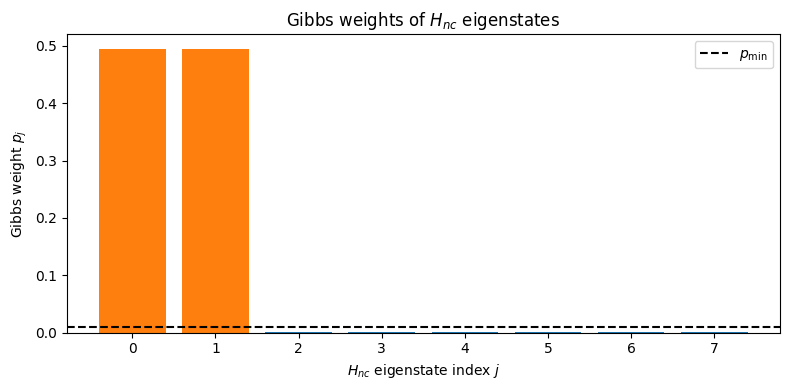

In [12]:
# Plot 1: Gibbs weights
plt.figure(figsize=(8, 4))
colors = ['tab:orange' if i in selected else 'tab:blue' for i in range(len(evals_nc))]
plt.bar(np.arange(len(evals_nc)), weights, color=colors)
plt.axhline(p_min, color='black', linestyle='--', label=r'$p_{\min}$')
plt.xticks(np.arange(len(evals_nc)))
plt.xlabel(r'$H_{nc}$ eigenstate index $j$')
plt.ylabel(r'Gibbs weight $p_j$')
plt.title(r'Gibbs weights of $H_{nc}$ eigenstates')
plt.legend()
plt.tight_layout()
plt.show()


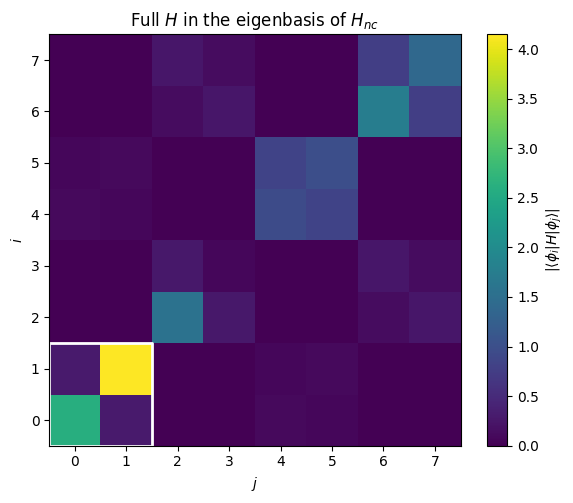

In [13]:
# Plot 2: |H| in the H_nc eigenbasis
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(H_in_nc_basis), origin='lower')
plt.colorbar(label=r'$|\langle \phi_i | H | \phi_j \rangle|$')
plt.xlabel(r'$j$')
plt.ylabel(r'$i$')
plt.title(r'Full $H$ in the eigenbasis of $H_{nc}$')

# Draw a box around the retained low sector.
if len(selected) > 0:
    i0 = selected[0] - 0.5
    i1 = selected[-1] + 0.5
    plt.plot([i0, i1, i1, i0, i0], [i0, i0, i1, i1, i0], color='white', linewidth=2)

plt.tight_layout()
plt.show()


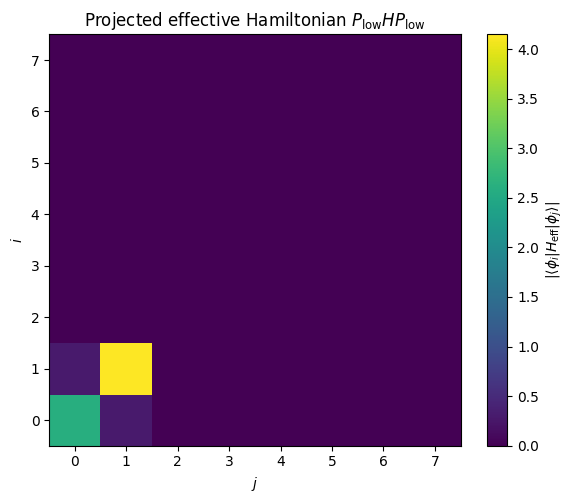

In [14]:
# Plot 3: |H_eff| in the H_nc eigenbasis
plt.figure(figsize=(6, 5))
plt.imshow(np.abs(H_eff_in_nc_basis), origin='lower')
plt.colorbar(label=r'$|\langle \phi_i | H_{\mathrm{eff}} | \phi_j \rangle|$')
plt.xlabel(r'$j$')
plt.ylabel(r'$i$')
plt.title(r'Projected effective Hamiltonian $P_{\mathrm{low}} H P_{\mathrm{low}}$')
plt.tight_layout()
plt.show()


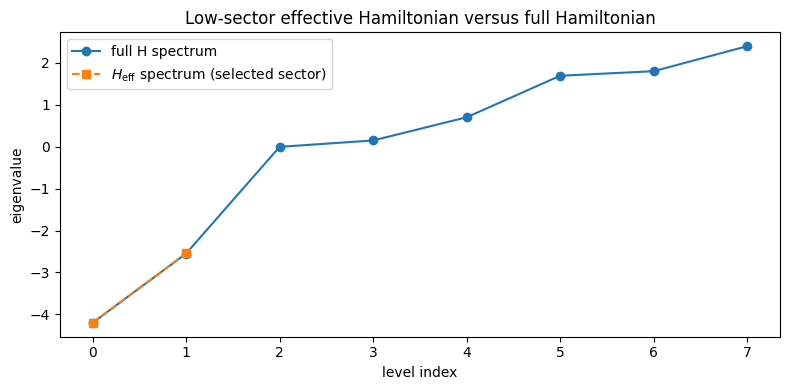

In [15]:
# Plot 4: compare the low part of the spectra
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(full_eigs)), full_eigs, 'o-', label='full H spectrum')
plt.plot(np.arange(len(eff_sector_eigs)), eff_sector_eigs, 's--', label=r'$H_{\mathrm{eff}}$ spectrum (selected sector)')
plt.xlabel('level index')
plt.ylabel('eigenvalue')
plt.title(r'Low-sector effective Hamiltonian versus full Hamiltonian')
plt.legend()
plt.tight_layout()
plt.show()


## What to take away

### Paper-faithful CS-VQE picture

The original CS-VQE paper does **not** diagonalize $H_{nc}$ and keep a Gibbs-selected thermal sector. Instead, it:

1. finds a noncontextual model for $H_{nc}$,
2. finds the noncontextual ground state,
3. uses the associated noncontextual generators to define a contextual subspace,
4. restricts the contextual correction to that subspace.

### Gibbs low-sector extension

The Gibbs-sector method implemented above is a **different projector construction**:

- choose the low-temperature sector using the eigenpairs of $H_{nc}$,
- then project the **full** Hamiltonian $H = H_{nc} + H_c$ into that sector.

This is often a natural thing to try if your physical motivation is:

> “At inverse temperature $\beta$, only the high-weight eigenstates of $H_{nc}$ should matter.”

Then the reduced operator you actually want is
\[
H_{\mathrm{eff}} = P_{\mathrm{low}} H P_{\mathrm{low}},
\]
not just the projection of $H_c$ by itself.

That is because once you keep more than one $H_{nc}$ sector, the relative low-energy ordering coming from $H_{nc}$ still matters inside the retained subspace.